In [ ]:
# Importación de librerías

import pandas as pd
import numpy as numpy

pd.set_option("display.max_columns", None)

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# 1) poner todo en inglés
# 2) añadir interpretaciones en fases 2 y 3

# hoja de ruta:
EXPLORACION:
1) Cargamos los csv
2) Exploración básica (head, tail, sample), echar un vistazo y ver que se carga correctamente. ¿index_col = 0? --> solo si quiero que esa columna sea un indice, para eso es util echar un vistazo al df (en este caso no hace falta index_col = 0)
3) Forma csv y nombre columnas. Entender qué información contiene cada uno. 
4) Info --> tipos de datos, nombres columnas, numero de no nulos.
5) Describe numericos (medidas descriptivas media, mediana, desviacion estandar, max, min...)
6) Describe categoricos --> Recuento, numero categorias, moda y frecuencia absoluta moda. 
7) Nulos?
8) Duplicados?
(en cada fase de la exploración vamos tomando notas de los cambios que creemos que tendremos que hacer en fase de limpieza)
LIMPIEZA:
1) Homogeneizacion nombres columnas
2) Homogeneizacion categorias, decimales en flotantes...
3) Eliminar duplicados
4) Gestionar nulos
5) Unir dataframes

## Fase 1 - Exploración y Limpieza
### 1. Exploración inicial

In [ ]:
df_flight_activity = pd.read_csv("data/customer_flight_activity.csv")

In [ ]:
df_loyalty_history = pd.read_csv("data/customer_loyalty_history.csv")

In [104]:
def basic_exploration(df):
    display(df.head(2))
    display(df.tail(2))
    display(df.sample(2))
    print(df.info())
    print(f"El dataframe {df} tiene {df.shape[0]} filas y {df.shape[1]} columnas")

In [ ]:
basic_exploration(df_flight_activity)

In [ ]:
basic_exploration(df_loyalty_history)

### 2. Limpieza de datos

- Analisis descriptivo

In [ ]:
df_loyalty_history.columns

In [ ]:
df_flight_activity.columns

In [ ]:
# preguntar si está bien poner la función así

In [62]:
def descriptive_analysis(df):
    print("NUMÉRICAS")
    display(df.describe().T)
    
    categoricas = df.select_dtypes(include="object")
    
    if not categoricas.empty:
        print("CATEGÓRICAS")
        display(categoricas.describe().T)
    else:
        print(f"No existen datos categóricos para el dataframe")

In [ ]:
descriptive_analysis(df_flight_activity)

In [ ]:
descriptive_analysis(df_loyalty_history)

- Homogeneización columnas

In [68]:
def clean_columns(df):
    new_cols = {
        col: col.lower().replace(" ", "_").replace(".", "_").replace("-", "_")
        for col in df.columns
    }
    df.rename(columns=new_cols, inplace=True)
    return df

In [ ]:
clean_columns(df_loyalty_history)

In [ ]:
clean_columns(df_flight_activity)

- Eliminación duplicados

In [ ]:
def delete_duplicates(df):
    df = df.drop_duplicates(inplace=True)
    return df

In [ ]:
print(df_flight_activity.duplicated().sum())

In [ ]:
print(df_loyalty_history.duplicated().sum())

In [75]:
delete_duplicates(df_flight_activity)

In [76]:
delete_duplicates(df_loyalty_history)

In [ ]:
print(df_flight_activity.duplicated().sum())

In [ ]:
print(df_loyalty_history.duplicated().sum())

In [ ]:
df_loyalty_history.info()

- Cambio de tipos de dato

In [87]:
def change_months(df):
    months_dict = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril",
                        5: "Mayo", 6: "Junio", 7: "Julio", 8: "Agosto",
                        9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}
    
    months_columns = [col for col in df.columns 
                      if "month" in col.lower()]
    
    for col in months_columns:
        df[col] = df[col].replace(months_dict)

In [89]:
change_months(df_flight_activity)

In [ ]:
df_flight_activity.head(2)

In [91]:
change_months(df_loyalty_history)

In [ ]:
df_loyalty_history.head(2)

In [ ]:
df_flight_activity.dtypes

In [ ]:
df_loyalty_history.dtypes

In [98]:
def convert_to_float(df, columns):
    df[columns] = df[columns].astype(float)
    return df

In [ ]:
convert_to_float(df_flight_activity,["distance", "dollar_cost_points_redeemed"])

In [119]:
def convert_to_int(df, columns):
    df[columns] = df[columns].astype("Int64")
    return df

In [ ]:
convert_to_int(df_loyalty_history, "cancellation_year")

- Tratamiento datos nulos y atípicos

In [125]:
(df_loyalty_history["salary"] < 0).sum()


np.int64(20)

In [ ]:
def correct_negative_salaries(df, columna):
    df[columna] = df[columna].where(df[columna] >= 0, numpy.nan)
    return df

In [126]:
df_loyalty_history = correct_negative_salaries(df_loyalty_history, 'salary')

In [127]:
(df_loyalty_history["salary"] < 0).sum()


np.int64(0)

In [ ]:
print(df_loyalty_history.isnull().sum())
print(df_flight_activity.isnull().sum())

In [129]:
def resumen_nulos(df):
    nulos = (df.isnull().sum() / len(df) * 100).reset_index()
    nulos.columns = ["columna", "%_nulos"]
    return nulos[nulos["%_nulos"] > 0]

In [135]:
resumen_nulos(df_loyalty_history)

,columna,%_nulos
7,salary,25.440640
14,cancellation_year,87.650117
15,cancellation_month,87.650117


In [139]:
df_loyalty_history["salary"].value_counts(dropna=False)

salary
NaN         4258
101933.0      23
62283.0       14
51573.0       14
61809.0       14
            ... 
65798.0        1
30767.0        1
46971.0        1
86159.0        1
98892.0        1
Name: count, Length: 5871, dtype: int64

In [141]:
df_loyalty_history['salary'].isnull().mean() * 100

np.float64(25.44064049710223)

In [147]:
avg_salary = (df_loyalty_history['salary'].median())

In [144]:
print(df_loyalty_history['salary'].mean())
print(df_loyalty_history['salary'].median())

79429.57264203862
73510.0


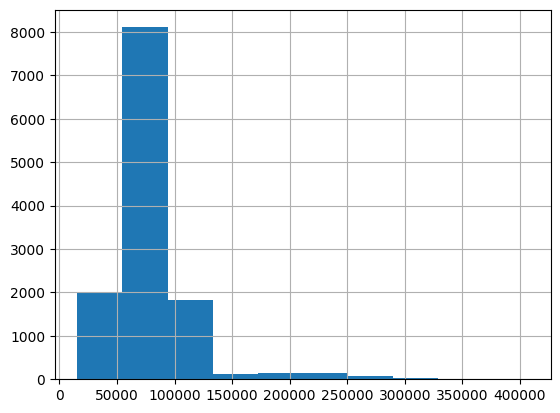

In [146]:
df_loyalty_history["salary"].hist();

In [148]:
salary_range = df_loyalty_history["salary"].max() - df_loyalty_history["salary"].min()
salary_variation_coefficient = (df_loyalty_history["salary"].std() / avg_salary) * 100
print(salary_range)
print(salary_variation_coefficient.round(2))

391619.0
47.24


In [149]:
df_loyalty_history['salary'] = df_loyalty_history['salary'].fillna(df_loyalty_history['salary'].median())

In [150]:
df_loyalty_history["salary"].value_counts(dropna=False)

salary
73510.0     4260
101933.0      23
61809.0       14
51573.0       14
62283.0       14
            ... 
59220.0        1
31456.0        1
57734.0        1
216901.0       1
73624.0        1
Name: count, Length: 5870, dtype: int64

C:\Users\al101\AppData\Local\Temp\ipykernel_10268\3512195714.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend();


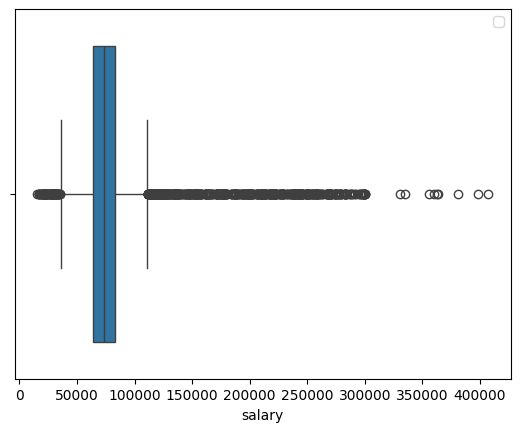

In [151]:
sns.boxplot(data=df_loyalty_history, x="salary")

plt.legend();

In [152]:
df_flight_activity.to_csv("clean_flight_activity.csv", index=False)
df_loyalty_history.to_csv("clean_df_loyalty_history.csv", index=False)